In [1]:
# imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Loading in the Data

In [2]:
YCRDataPreparedFilepath = '../data/FinalCleanYelpData.csv'

In [3]:
YCRDataPrepared = pd.read_csv(YCRDataPreparedFilepath)
YCRDataPrepared

,Name,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Category,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
0,Ravintola Vinkkeli,60.163900,24.946410,993.930059,Most Expensive,5.0,652.820553,104.417207,993.930059,28,Modern European,60.164,24.946,993.930,652.821
1,Baskeri & Basso,60.157873,24.934694,906.269559,Affordable,4.8,673.116165,83.377593,978.824142,16,Bistros,60.158,24.935,906.270,673.116
2,Chef & Sommelier,60.157660,24.942540,489.112498,Most Expensive,4.8,641.800023,134.034975,943.511457,14,Scandinavian,60.158,24.943,489.112,641.800
3,Spis,60.163631,24.947679,910.667273,Most Expensive,4.8,636.883659,122.448928,951.268827,24,Scandinavian,60.164,24.948,910.667,636.884
4,Ani,60.157150,24.933661,941.072231,Affordable,4.5,718.839949,163.361331,995.254401,16,Turkish,60.157,24.934,941.072,718.840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9730,Karhu Ministeri,60.189571,24.917259,705.595387,Affordable,3.3,511.016285,192.545596,902.743177,11,Pubs,60.190,24.917,705.595,511.016
9731,Ravintola Lehtovaara,60.183600,24.915930,542.047402,Most Expensive,3.3,592.193958,190.699671,961.362096,9,Scandinavian,60.184,24.916,542.047,592.194
9732,Boatip,60.184929,24.941851,891.112679,Most Affordable,4.0,858.743008,826.373336,891.112679,2,Thai,60.185,24.942,891.113,858.743
9733,Diyalo,60.184676,24.923223,125.893234,Affordable,4.0,527.561874,125.893234,909.115155,7,Himalayan/Nepalese,60.185,24.923,125.893,527.562


# Building a regression model

In [4]:
# X are features Y is target.
X_Numeric = YCRDataPrepared[['Rounded Latitude','Rounded Longitude','Rating','Rounded Distance','Rounded Distance_mean']]
y = YCRDataPrepared['Bike Spots Near']

In [5]:
X_Numeric

,Rounded Latitude,Rounded Longitude,Rating,Rounded Distance,Rounded Distance_mean
0,60.164,24.946,5.0,993.930,652.821
1,60.158,24.935,4.8,906.270,673.116
2,60.158,24.943,4.8,489.112,641.800
3,60.164,24.948,4.8,910.667,636.884
4,60.157,24.934,4.5,941.072,718.840
...,...,...,...,...,...
9730,60.190,24.917,3.3,705.595,511.016
9731,60.184,24.916,3.3,542.047,592.194
9732,60.185,24.942,4.0,891.113,858.743
9733,60.185,24.923,4.0,125.893,527.562


In [6]:
y

0       28
1       16
2       14
3       24
4       16
        ..
9730    11
9731     9
9732     2
9733     7
9734     5
Name: Bike Spots Near, Length: 9735, dtype: int64

In [6]:
# checking for correlation.
NumericCorrelationMatrix = YCRDataPrepared.corr(numeric_only=True)
NumericCorrelationMatrix

,Latitude,Longitude,Distance,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
Latitude,1.000000,0.332180,-0.072395,-0.291110,-0.225244,-0.141155,-0.127531,-0.136595,0.999970,0.332266,-0.072395,-0.225244
Longitude,0.332180,1.000000,0.010182,0.060689,0.031680,0.058445,-0.086827,0.015129,0.331948,0.999994,0.010182,0.031680
Distance,-0.072395,0.010182,1.000000,0.045317,0.321408,0.216417,0.147196,-0.024512,-0.072384,0.010194,1.000000,0.321408
Rating,-0.291110,0.060689,0.045317,1.000000,0.140995,0.000661,0.173716,0.416197,-0.291520,0.060767,0.045317,0.140995
Distance_mean,-0.225244,0.031680,0.321408,0.140995,1.000000,0.673341,0.457971,-0.076264,-0.225208,0.031717,0.321408,1.000000
Distance_min,-0.141155,0.058445,0.216417,0.000661,0.673341,1.000000,-0.090176,-0.394952,-0.141270,0.058352,0.216417,0.673340
Distance_max,-0.127531,-0.086827,0.147196,0.173716,0.457971,-0.090176,1.000000,0.380365,-0.127487,-0.086773,0.147196,0.457971
Bike Spots Near,-0.136595,0.015129,-0.024512,0.416197,-0.076264,-0.394952,0.380365,1.000000,-0.136525,0.015216,-0.024512,-0.076264
Rounded Latitude,0.999970,0.331948,-0.072384,-0.291520,-0.225208,-0.141270,-0.127487,-0.136525,1.000000,0.332035,-0.072384,-0.225208
Rounded Longitude,0.332266,0.999994,0.010194,0.060767,0.031717,0.058352,-0.086773,0.015216,0.332035,1.000000,0.010194,0.031717


In [44]:
# showing if anything has high correlation. 0.7 is the threshold
def HighlyCorrelatedFeatures(CorrelationMatrix):
    '''
    Identify all feature combinations that have high (0.7 or greater) correlation.
    
    Args:
        CorrelationMatrix (DataFrame): the correlation matrix of the data that is being interpreted.

    Returns:
        HighCorrelation (DataFrame): contains three columns with all feature combinations that are highly correlated.
        
            Feature 1 (string): the first of the 2 features that are highly correlated.
            Feature 2 (string): the second of the 2 features that are highly correlated.
            Correlation (float): the correlation of the two features from the correlation matrix.

    '''
    # creating a dictionary to store any pairs
    HighCorr = {}

    # Iterate over the correlation matrix
    for i in range(len(CorrelationMatrix.columns)):
        for j in range(i+1, len(CorrelationMatrix.columns)):  # avoiding duplicate pairs
            Feature1 = CorrelationMatrix.columns[i]
            Feature2 = CorrelationMatrix.columns[j]
            CorrValue = CorrelationMatrix.iloc[i, j]

            if abs(CorrValue) > 0.7:
                HighCorr[(Feature1, Feature2)] = CorrValue


    # converting into a dataframe
    HighCorrelation = pd.DataFrame(
        [(k[0], k[1], v) for k, v in HighCorr.items()],
        columns=["Feature 1", "Feature 2", "Correlation"]
    )

    return HighCorrelation

In [8]:
HighlyCorrelatedFeatures(NumericCorrelationMatrix)

,Feature 1,Feature 2,Correlation
0,Latitude,Rounded Latitude,0.999970
1,Longitude,Rounded Longitude,0.999994
2,Distance,Rounded Distance,1.000000
3,Distance_mean,Rounded Distance_mean,1.000000


The closer a value is to 1, the more correlated. There are no codependency issues here. The high correlations shown here are between values and their rounded counterparts.

In [9]:
# splitting the data
numeric_X_train, numeric_X_test, numeric_y_train, numeric_y_test = train_test_split(X_Numeric,y, test_size=0.2, random_state=42)

## streamlining model

In [5]:
def ExplanationAndErrors(Model, X, y):
    '''
    Makes calculations to determine how much a model explains and how much error it has.

    Args:
        Model (model): the model used to make predictions.
        X (dataframe): the features used to make the prediction. either training or testing.
        y (series): the actual target values that match up with the features. either training or testing. compared against y_pred.

    Returns:
        The R-squared, Adjusted R-squared, Mean Squared Error, and Root Mean Squared Error calculated using the selected data.

        ModelR2 (float): R-squared. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
        ModelAdjR2 (float): Adjusting ModelR2 by taking into account the amount of features and how they affect the model.
        ModelMSE (float): The square of what predictions are off by on average.
        ModelRMSE (float): What predictions are off by on average.

    '''
    y_pred = Model.predict(X)

    # calculating R^2 (Coefficient of Determination)
    ModelR2 = r2_score(y,y_pred)
    print(f'R^2: {ModelR2}')
    
    # adjusted R^2
    ModelAdjR2 = 1-(((1-ModelR2)*(len(X)-1))/(len(X)-len(X.columns)-1))
    print(f'Adjusted R^2: {ModelAdjR2}')

    # evaluating the model
    ModelMSE = mean_squared_error(y, y_pred)
    print(f'Mean Squared Error: {ModelMSE}')
    # getting RMSE to have more interpretability 
    ModelRMSE = np.sqrt(ModelMSE)
    print(f'Root Mean Squared Error: {ModelRMSE}')
    return ModelR2, ModelAdjR2, ModelMSE, ModelRMSE

In [6]:
def ModelCalculations(Model, BetaHat, X, y):
    '''
    Makes calculations about a linear regression model to be used in interpreting the predictive power of the model.

    Args:
        Model (linear regression model): the linear regression model used to make predictions
        BetaHat (float): the coefficients from the trained model
        X (dataframe): the features used to make the prediction. either training or testing.
        y (series): the actual target values that match up with the features. either training or testing. compared against y_pred

    Returns:
        Calculations that can be used to interpret the model's performance both on the training data and on the testing data.

        BetaHat: the coefficients from the trained model. how much the feature is calculated to affect the target.
        StandarErrorsBeta: 
        tStatistics:
        pValues:

    '''

    # calculating standard errors on the test set
    y_pred = Model.predict(X)
    Residuals = y - y_pred
    SSE = np.sum(Residuals**2)
    ResidualsDegreesOfFreedom = len(y) - len(BetaHat)

    # getting variance-covariance matrix
    X_Inverse = np.linalg.inv(X.T @ X)
    VarianceBeta = SSE / ResidualsDegreesOfFreedom * X_Inverse
    StandarErrorsBeta = np.sqrt(np.diag(VarianceBeta))

    # computing t-statistics
    tStatistics = BetaHat / StandarErrorsBeta

    # computing p-values
    pValues = 2 * stats.t.sf(np.abs(tStatistics), df=ResidualsDegreesOfFreedom)
    
    # computing RSS and TSS
    ResSumSq = np.sum((y - y_pred)**2)  # Residual Sum of Squares
    TotSumSq = np.sum((y - np.mean(y))**2)  # Total Sum of Squares

    # Degrees of freedom
    p = X.shape[1] - 1  # Number of predictors
    n = X.shape[0]  # Number of observations
    DegreesFreedomModel = p
    DegreesFreedomResidual = n - p - 1

    # computing F-statistic
    fStatistic = ((TotSumSq - ResSumSq) / DegreesFreedomModel) / (ResSumSq / DegreesFreedomResidual)

    # computing p-value for F-statistic
    fStatpVal = 1 - stats.f.cdf(fStatistic, DegreesFreedomModel, DegreesFreedomResidual)
    
    # showing results
    for i, (coef, se, t, p) in enumerate(zip(BetaHat, StandarErrorsBeta, tStatistics, pValues)):
        print(f"Coefficient {i}: β={coef:.4f}, SE={se:.3f}, t={t:.3f}, P>|t|={p:.3f}")

    print(f"F-statistic: {fStatistic:.3f}, Prob(F-statistic): {fStatpVal:.3f}")

    return BetaHat, StandarErrorsBeta, tStatistics, pValues

In [7]:
def LinearRegressionModel(X_train, X_test, y_train, y_test):
    '''
    Takes the split training and testing data. Trains an Ordinary Least Squares model. Displays calculations that can be used to interpret the model's performance both on the training data and on the testing data.
    
    Args:
        X_train (DataFrame): To be used to train the model. The numerical features used to try to predict the specified target.
        X_test (DataFrame): To be used to test the model. The numerical features used to try to predict the specified target.
        y_train (DataFrame): To be used to train the model. The specified target that the model is trying to predict.
        y_test (DataFrame): To be used to test the model. The specified target that the model is trying to predict.

    Returns:

        
        Calculations that can be used to interpret the model's performance both on the training data and on the testing data.
        
        trainModelR2 (float): R-squared calculated using the training data. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
        trainModelAdjR2 (float): Adjusting trainModelR2 by taking into account the amount of features and how they affect the model.
        trainModelMSE (float): The square of what predictions of the training data are off by on average.
        trainModelRMSE (float): What predictions of the training data are off by on average.
        testModelR2 (float): R-squared calculated using the testing data. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
        testModelAdjR2 (float): Adjusting testModelR2 by taking into account the amount of features and how they affect the model.
        testModelMSE (float): The square of what predictions of the testing data are off by on average.
        testModelRMSE (float): What predictions of the testing data are off by on average.

    '''
    # adding a constant
    X_train = sm.add_constant(X_train)
    X_test = sm.add_constant(X_test)
    
    # setting up the model
    LinReg = sm.OLS(y_train, X_train)
    
    # fitting the model
    Model = LinReg.fit()
    
    # displaying the model summary that has information on how the model performs on the training data
    ModelOutput = Model.summary()
    print(ModelOutput)
    
    # getting coefficients from the trained model
    BetaHat = Model.params

    print(f'Showing calculations made with X_train and y_train')
    trainModelR2, trainModelAdjR2, trainModelMSE, trainModelRMSE = ExplanationAndErrors(Model, X_train, y_train)

    print(f'R Squared: {trainModelR2}')
    print(f'Adjusted R Squared: {trainModelAdjR2}')
    print(f'Mean Squared Error: {trainModelMSE}')
    print(f'Root Mean Squared Error: {trainModelRMSE}')

    training_BetaHat, training_StandarErrorsBeta, training_tStatistics, training_pValues = ModelCalculations(Model, BetaHat, X_train, y_train)
    print(f'BetaHat: {training_BetaHat}')
    print(f'Standard Errors: {training_StandarErrorsBeta}')
    print(f't Statistics: {training_tStatistics}')
    print(f'p Values: {training_pValues}') 

    print() # visually breaking up results
    print(f'Showing calculations made with X_test and y_test')
    testModelR2, testModelAdjR2, testModelMSE, testModelRMSE = ExplanationAndErrors(Model, X_test, y_test)
    
    print(f'R Squared: {testModelR2}')
    print(f'Adjusted R Squared: {testModelAdjR2}')
    print(f'Mean Squared Error: {testModelMSE}')
    print(f'Root Mean Squared Error: {testModelRMSE}')

    testing_BetaHat, testing_StandarErrorsBeta, testing_tStatistics, testing_pValues = ModelCalculations(Model, BetaHat, X_test, y_test)
    print(f'BetaHat: {testing_BetaHat}')
    print(f'Standard Errors: {testing_StandarErrorsBeta}')
    print(f't Statistics: {testing_tStatistics}')
    print(f'p Values: {testing_pValues}') 
    
    # comparing the values from training to testing

    # t-value represents how many standard errors away from zero the estimated coefficinet is. higher t-value tells us the coefficient is significantly different from zero; relationship between feature and target.
    
    # Set up figure with 2 rows and 2 columns
    graphColours = plt.cm.tab10(np.arange(len(training_BetaHat))) 

    fig, ax = plt.subplots(2, 2, figsize=(15, 8))

    # BetaHat
    for i, coef in enumerate(training_BetaHat.index):
        ax[0,0].plot([trainModelAdjR2, testModelAdjR2]
                , [training_BetaHat.iloc[i], testing_BetaHat.iloc[i]]
                , color=graphColours[i]
                , alpha=0.5
                , marker='o'
                , label=coef)
        
    ax[0,0].set_xlabel('Adjusted R Squared')
    ax[0,0].set_ylabel('Coefficient Value')
    ax[0,0].set_title('Training vs Testing Coefficients')
    
    
    # Standard Errors
    for i, coef in np.ndenumerate(training_StandarErrorsBeta):
        ax[0,1].plot([trainModelAdjR2, testModelAdjR2]
                , [training_StandarErrorsBeta[i], testing_StandarErrorsBeta[i]]
                , color=graphColours[i]
                , alpha=0.5
                , marker='o'
                , label=coef)
        
    ax[0,1].set_xlabel('Adjusted R Squared')
    ax[0,1].set_ylabel('Standard Errors')
    ax[0,1].set_title('Training vs Testing Standard Errors')


    # t Statistics
    for i, coef in np.ndenumerate(training_tStatistics):
        ax[1,0].plot([trainModelAdjR2, testModelAdjR2]
                , [training_tStatistics.iloc[i], testing_tStatistics.iloc[i]]
                , color=graphColours[i]
                , alpha=0.5
                , marker='o'
                , label=coef)

    ax[1,0].set_xlabel('Adjusted R Squared')
    ax[1,0].set_ylabel('t Statistics')
    ax[1,0].set_title('Training vs Testing t Statistics')


    # p values
    for i, coef in np.ndenumerate(training_pValues):
        ax[1,1].plot([trainModelAdjR2, testModelAdjR2]
                , [training_pValues[i], testing_pValues[i]]
                , color=graphColours[i]
                , alpha=0.5
                , marker='o'
                , label=coef)

    # Visual indicator for p value cutoff
    ax[1,1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5) 
    ax[1,1].text(x=trainModelAdjR2, y=0.05 + 0.025, s='p = 0.05',
             color='black', fontsize=9, ha='left')

    ax[1,1].set_xlabel('Adjusted R Squared')
    ax[1,1].set_ylabel('p values')
    ax[1,1].set_title('Training vs Testing p values')


    # Adjust layout to show legend clearly
    plt.subplots_adjust(wspace=0.6, hspace=0.6, left=0.1, right=0.9, top=0.9, bottom=0.1)

    # Set up legend for clarity
    handles, labels = ax[0,0].get_legend_handles_labels()

    fig.legend(handles, labels
               , loc='center'
               , bbox_to_anchor=(0.5, 0.5)
               , fontsize=10
               , title='Coefficients'
               , frameon=True)

    plt.show()

    return trainModelR2, trainModelAdjR2, trainModelMSE, trainModelRMSE, testModelR2, testModelAdjR2, testModelMSE, testModelRMSE

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     367.3
Date:                Tue, 24 Jun 2025   Prob (F-statistic):               0.00
Time:                        10:19:17   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7782   BIC:                         5.256e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   495.23

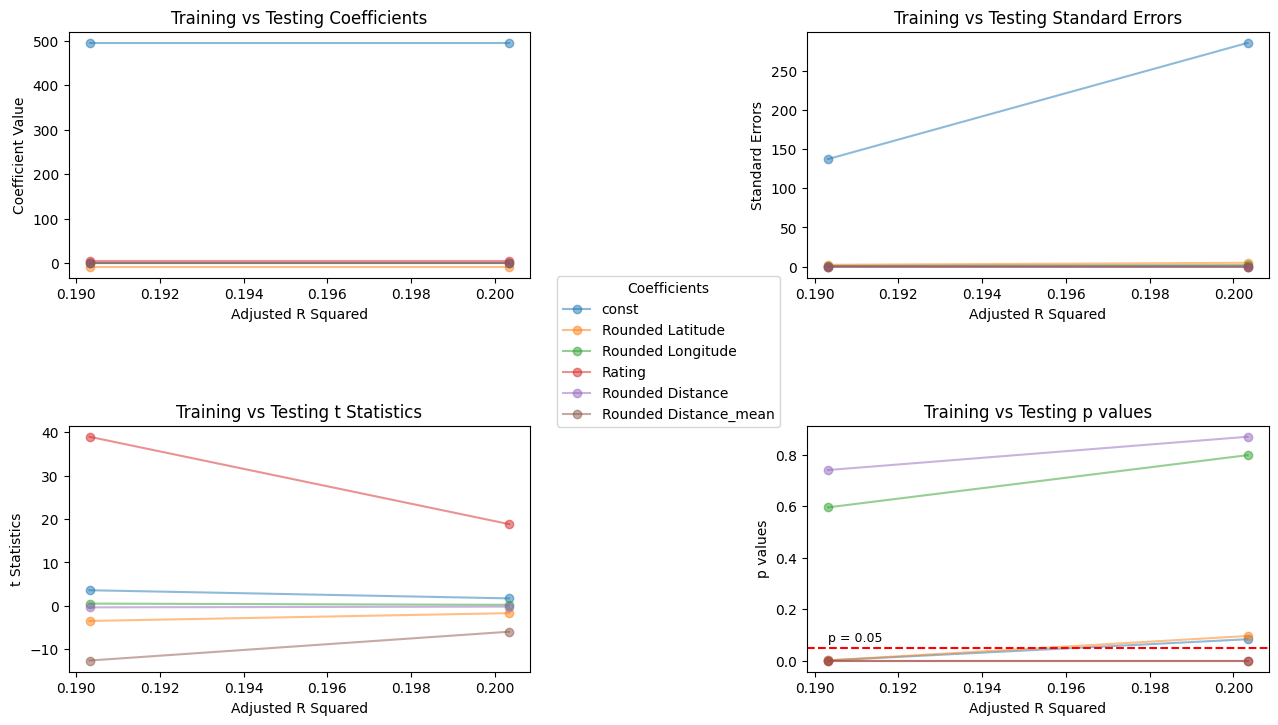

In [9]:
OLS1R2train, OLS1AdjR2train, OLS1MSEtrain, OLS1RMSEtrain, OLS1R2test, OLS1AdjR2test, OLS1MSEtest, OLS1RMSEtest = LinearRegressionModel(numeric_X_train, numeric_X_test, numeric_y_train, numeric_y_test)

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Graph Information</h3>
<table>
  <tr>
    <th>Coefficients
    </th>
    <th>Standard Errors
    </th>
    <th>t statistics and p values
    </th>
  </tr>
  <tr>
    <td>Calculated based on the training data. This value should be and is the same for both training and testing data.<br>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
    <td>The variation in the means accross multiple data points.
    </td>
    <td>
      <p>(estimated coefficient) / (standard error)
      </p>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <p>Tells us how many standard errors away from zero the estimated coefficient is. The further away from zero the t-statistic is, the stronger evidence against the null hypothesis.
      </p>
    </td>
  </tr>
  <tr>
    <td>The coefficients are the same between training and testing. The graph indicates to us that the model calculations have been performed correctly.
    </td>
    <td>
      <p>The standard errors of the <span class='feature'>features</span> are relatively similar across the training and testing data. This indicates that the model is able to predict the testing data about the same as it is the training data. This suggests low overfitting.
      </p>
      <p> The relatively large change in standard error of the constant between training and testing suggests that the mean of the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is different between the training and testing data.
      </p>
    </td>
    <td>Only <span class='feature'>Rating</span> and <span class='feature'>Rounded Distance Mean</span> are able to reject the null hypothesis for both training and testing data. <span class='feature'>Rounded Distance</span> has the highest p values and can be removed from the model first.
    </td>
  </tr>
</table>

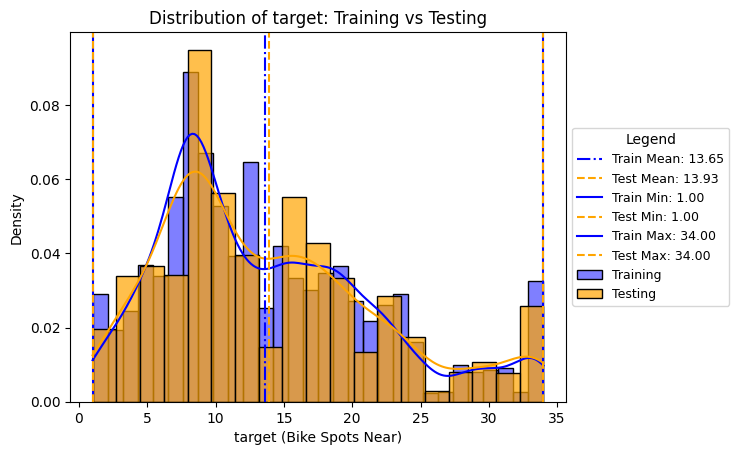

In [39]:
# Compare the target from training to testing
sns.histplot(numeric_y_train, color='blue', label='Training', kde=True, stat='density')
sns.histplot(numeric_y_test, color='orange', label='Testing', kde=True, stat='density', alpha=0.7)

# Line indicator of mean
plt.axvline(np.mean(numeric_y_train), color='blue', linestyle='-.', label=f"Train Mean: {np.mean(numeric_y_train):.2f}")
plt.axvline(np.mean(numeric_y_test), color='orange', linestyle='--', label=f"Test Mean: {np.mean(numeric_y_test):.2f}")

# Line indicator of minimum
plt.axvline(np.min(numeric_y_train), color='blue', linestyle='-', label=f"Train Min: {np.min(numeric_y_train):.2f}")
plt.axvline(np.min(numeric_y_test), color='orange', linestyle='--', label=f"Test Min: {np.min(numeric_y_test):.2f}")

# Line indicator of maximum
plt.axvline(np.max(numeric_y_train), color='blue', linestyle='-', label=f"Train Max: {np.max(numeric_y_train):.2f}")
plt.axvline(np.max(numeric_y_test), color='orange', linestyle='--', label=f"Test Max: {np.max(numeric_y_test):.2f}")

# Title and Axes labels
plt.title('Distribution of target: Training vs Testing')
plt.xlabel('target (Bike Spots Near)')
plt.ylabel('Density')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, title='Legend')

We can see that the training and testing data sets have relatively similar means and the same minimum and maximum values. The larger difference is how many data points have what amounts of bike spots near.

## Model Output and Interpretation
---

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 495.2383 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.203
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.190
            </td>
            <td>0.200
            </td>
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.615
            </td>
            <td>52.256
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.044
          </td>
          <td>7.229
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>
          The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 495.2383 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.083
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Latitude
      </span>
    </td>
    <td class='center'>
      <table class='SplitRow'>
        <tr>
          <td>0.001
          </td>
          <td>0.096
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-8.3100
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Longitude
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.596
          </td>
          <td>0.799
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>+0.5343
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.5630
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.741
          </td>
          <td>0.871
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-0.0001
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0132
    </td>
  </tr>
</table>

In [11]:
class StoredModelCalculations:
    def __init__(self):
        '''
        The initial list of results. This gets added to using add_result

        Args:
            self (list): the list of dictionaries that contains results.

        Returns:
            Initializes an empty list.
            self.results (list): initialized list to contain model calculations.

        '''
        self.results = []

    def AddResults(self, modelName, trainModelR2, trainModelAdjR2, trainModelMSE, trainModelRMSE, testModelR2, testModelAdjR2, testModelMSE, testModelRMSE):
        '''
        Adding a result dictionary to the list of results.

        Args:
            self (list): the list of dictionaries that contains results.
            modelName (string): the name of the model that is having results stored.
            trainModelR2 (float): the R-squared of the model's training data.
            trainModelAdjR2 (float): the Adjusted R-squared of the model's training data.
            trainModelMSE (float): the Mean Squared Error of the model's training data.
            trainModelRMSE (float): the Root Mean Squared Error of the model's training data.
            testModelR2 (float): the R-squared of the model's testing data.
            testModelAdjR2 (float): the Adjusted R-squared of the model's testing data.
            testModelMSE (float): the Mean Squared Error of the model's testing data.
            testModelRMSE (float): the Root Mean Squared Error of the model's testing data.

        Returns:
            Appends a dictionary to the list of results.
            
            result (dictionary): a dictionary containing values calculated from a given model:
                trainModelR2 (float): R-squared calculated using the training data. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
                trainModelAdjR2 (float): Adjusting trainModelR2 by taking into account the amount of features and how they affect the model.
                trainModelMSE (float): The square of what predictions of the training data are off by on average.
                trainModelRMSE (float): What predictions of the training data are off by on average.
                testModelR2 (float): R-squared calculated using the testing data. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
                testModelAdjR2 (float): Adjusting testModelR2 by taking into account the amount of features and how they affect the model.
                testModelMSE (float): The square of what predictions of the testing data are off by on average.
                testModelRMSE (float): What predictions of the testing data are off by on average.
                

        '''
        result = {
            'model' : modelName
            ,'trainModelR2': trainModelR2
            , 'trainModelAdjR2': trainModelAdjR2
            , 'trainModelMSE': trainModelMSE
            , 'trainModelRMSE': trainModelRMSE
            , 'testModelR2': testModelR2
            , 'testModelAdjR2': testModelAdjR2
            , 'testModelMSE': testModelMSE
            , 'testModelRMSE': testModelRMSE
        }
        
        self.results.append(result)

    def GetResults(self):
        '''
        Getting the list of results.

        Args:
            self (list): the list of dictionaries that contains results.

        Returns:
            The result dictionaries stored in the result list.

            self.results (list): list containing model calculations of various models:
                trainModelR2 (float): R-squared calculated using the training data. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
                trainModelAdjR2 (float): Adjusting trainModelR2 by taking into account the amount of features and how they affect the model.
                trainModelMSE (float): The square of what predictions of the training data are off by on average.
                trainModelRMSE (float): What predictions of the training data are off by on average.
                testModelR2 (float): R-squared calculated using the testing data. How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
                testModelAdjR2 (float): Adjusting testModelR2 by taking into account the amount of features and how they affect the model.
                testModelMSE (float): The square of what predictions of the testing data are off by on average.
                testModelRMSE (float): What predictions of the testing data are off by on average.
            
        '''
        return self.results

In [12]:
ResultsStore = StoredModelCalculations()

In [13]:
ResultsStore.AddResults('OLS1', OLS1R2train, OLS1AdjR2train, OLS1MSEtrain, OLS1RMSEtrain, OLS1R2test, OLS1AdjR2test, OLS1MSEtest, OLS1RMSEtest)

## Adjustment 1

In [14]:
# adjusting the model by removing the feature with the highest p-value. also adjusting the test data to work with this change.
X_trainAdjusted = numeric_X_train.drop(columns=['Rounded Distance'])
X_testAdjusted = numeric_X_test.drop(columns=['Rounded Distance'])
print(f'total columns in X_trainAdjusted = total columns in X_testAdjusted: {len(X_trainAdjusted.columns) == len(X_testAdjusted.columns)}')

total columns in X_trainAdjusted = total columns in X_testAdjusted: True


                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     459.2
Date:                Tue, 24 Jun 2025   Prob (F-statistic):               0.00
Time:                        10:19:50   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7783   BIC:                         5.255e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   495.52

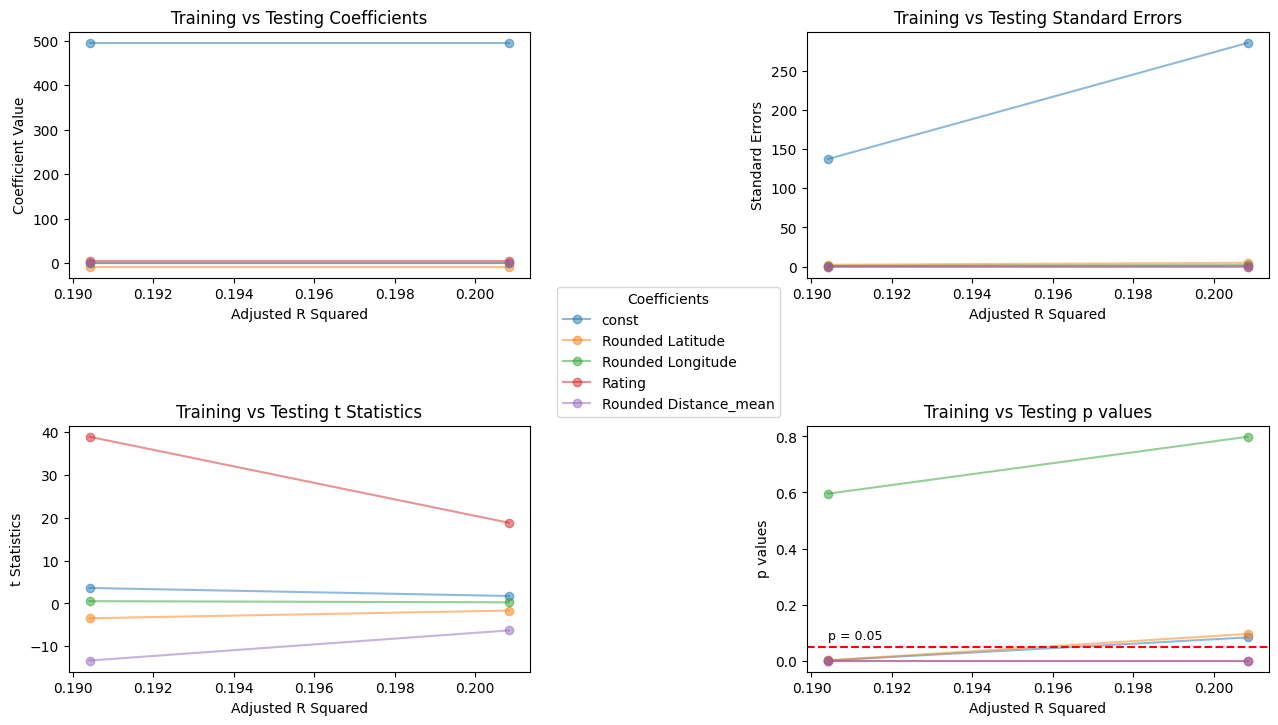

In [ ]:
OLS2R2train, OLS2AdjR2train, OLS2MSEtrain, OLS2RMSEtrain, OLS2R2test, OLS2AdjR2test, OLS2MSEtest, OLS2RMSEtest = LinearRegressionModel(X_trainAdjusted, X_testAdjusted, numeric_y_train, numeric_y_test)

In [16]:
ResultsStore.AddResults('OLS2', OLS2R2train, OLS2AdjR2train, OLS2MSEtrain, OLS2RMSEtrain, OLS2R2test, OLS2AdjR2test, OLS2MSEtest, OLS2RMSEtest)

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Graph Information</h3>
<table>
  <tr>
    <th>Coefficients
    </th>
    <th>Standard Errors
    </th>
    <th>t statistics and p values
    </th>
  </tr>
  <tr>
    <td>Calculated based on the training data. This value should be and is the same for both training and testing data.<br>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
    <td>The variation in the means accross multiple data points.
    </td>
    <td>
      <p>(estimated coefficient) / (standard error)
      </p>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <p>Tells us how many standard errors away from zero the estimated coefficient is. The further away from zero the t-statistic is, the stronger evidence against the null hypothesis.
      </p>
    </td>
  </tr>
  <tr>
    <td>The coefficients are the same between training and testing. The graph indicates to us that the model calculations have been performed correctly.
    </td>
    <td>
      <p>The standard errors of the <span class='feature'>features</span> are relatively similar across the training and testing data. This indicates that the model is able to predict the testing data about the same as it is the training data. This suggests low overfitting.
      </p>
      <p> The relatively large change in standard error of the constant between training and testing suggests that the mean of the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is different between the training and testing data.
      </p>
      <p>Review has shown that it's not the mean of the <span class='target'>target</span> that is different between training and testing data sets, but the distribution of the <span class='target'>target</span> of <span class='target'> within the data sets.
      </p>
    </td>
    <td>Only <span class='feature'>Rating</span> and <span class='feature'>Rounded Distance Mean</span> are able to reject the null hypothesis for both training and testing data. <span class='feature'>Rounded Longitude</span> has the highest p values and can be removed from the model first.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 495.5222 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.203
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.201
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.616
            </td>
            <td>52.250
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.044
          </td>
          <td>7.228
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>
          The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 495.5222 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.082
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Latitude
      </span>
    </td>
    <td class='center'>
      <table class='SplitRow'>
        <tr>
          <td>0.001
          </td>
          <td>0.095
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-8.3148
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Longitude
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.596
          </td>
          <td>0.799
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>+0.5346
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.5631
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0133
    </td>
  </tr>
</table>

## Adjustment 2

In [17]:
# adjusting the model by removing the feature with the highest p-value. also adjusting the test data to work with this change.
X_trainAdjusted2 = X_trainAdjusted.drop(columns=['Rounded Longitude'])
X_testAdjusted2 = X_testAdjusted.drop(columns=['Rounded Longitude'])
print(f'total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: {len(X_trainAdjusted2.columns) == len(X_testAdjusted2.columns)}')

total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: True


                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     612.2
Date:                Tue, 24 Jun 2025   Prob (F-statistic):               0.00
Time:                        10:30:22   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7784   BIC:                         5.254e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   479.58

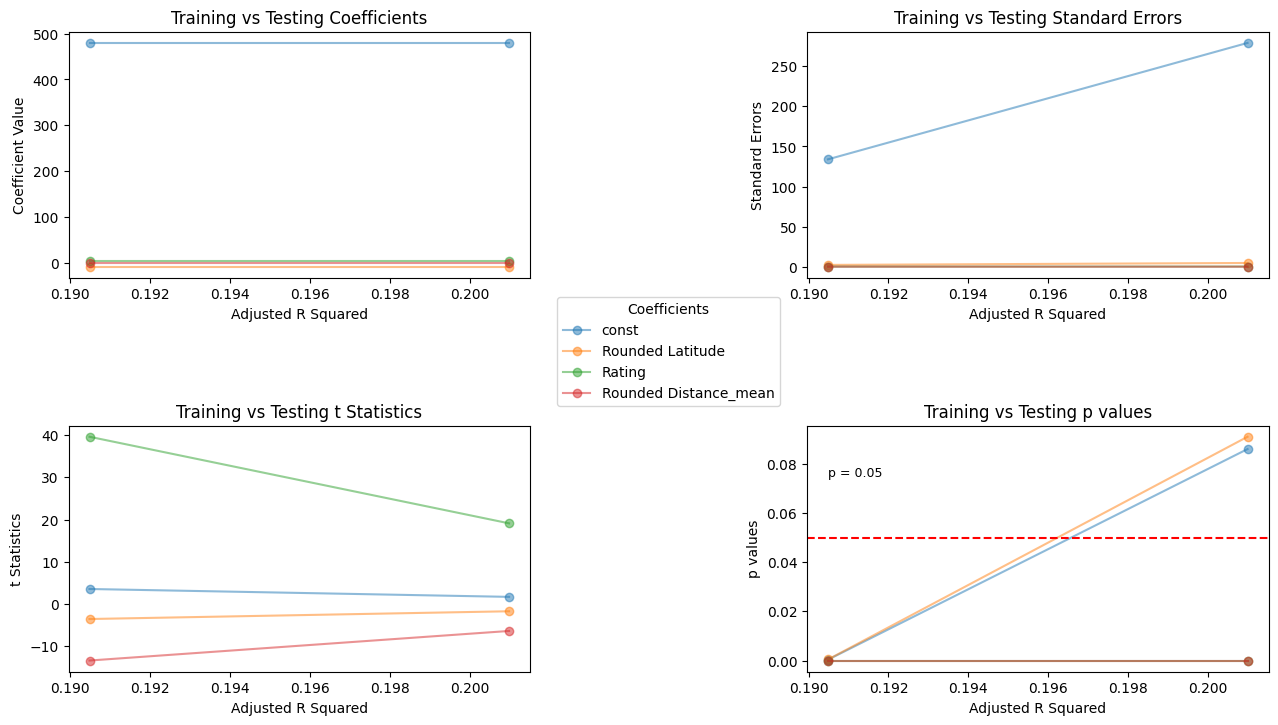

In [17]:
OLS3R2train, OLS3AdjR2train, OLS3MSEtrain, OLS3RMSEtrain, OLS3R2test, OLS3AdjR2test, OLS3MSEtest, OLS3RMSEtest = LinearRegressionModel(X_trainAdjusted2, X_testAdjusted2, numeric_y_train, numeric_y_test)

In [19]:
ResultsStore.AddResults('OLS3', OLS3R2train, OLS3AdjR2train, OLS3MSEtrain, OLS3RMSEtrain, OLS3R2test, OLS3AdjR2test, OLS3MSEtest, OLS3RMSEtest)

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Graph Information</h3>
<table>
  <tr>
    <th>Coefficients
    </th>
    <th>Standard Errors
    </th>
    <th>t statistics and p values
    </th>
  </tr>
  <tr>
    <td>Calculated based on the training data. This value should be and is the same for both training and testing data.<br>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
    <td>The variation in the means accross multiple data points.
    </td>
    <td>
      <p>(estimated coefficient) / (standard error)
      </p>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <p>Tells us how many standard errors away from zero the estimated coefficient is. The further away from zero the t-statistic is, the stronger evidence against the null hypothesis.
      </p>
    </td>
  </tr>
  <tr>
    <td>The coefficients are the same between training and testing. The graph indicates to us that the model calculations have been performed correctly.
    </td>
    <td>
      <p>The standard errors of the <span class='feature'>features</span> are relatively similar across the training and testing data. This indicates that the model is able to predict the testing data about the same as it is the training data. This suggests low overfitting.
      </p>
      <p> The relatively large change in standard error of the constant between training and testing suggests that the mean of the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is different between the training and testing data.
      </p>
    </td>
    <td>Only <span class='feature'>Rating</span> and <span class='feature'>Rounded Distance Mean</span> are able to reject the null hypothesis for both training and testing data. <span class='feature'>Rounded Latitude</span> has the highest p values and can be removed from the model first.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 479.5840 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.203
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.191
            </td>
            <td>0.201
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.618
            </td>
            <td>52.267
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.044
          </td>
          <td>7.230
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
        <p>The MSE has increased after removing Rounded Longitude as a <span class='feature'>feature</span>. With that said, the t-test is a clearer indication of a <span class='feature'>feature's</span> relevance to the model.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 479.5840 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.086
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Latitude
      </span>
    <td class='center'>
      <table class='SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.091
          </td>
        </tr>
      </table>
      fail to reject
    </td>
    <td>-7.8297
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.5714
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0133
    </td>
  </tr>
</table>

## Adjustment 3

In [20]:
# adjusting the model by removing the feature with the highest p-value. also adjusting the test data to work with this change.
X_trainAdjusted3 = X_trainAdjusted2.drop(columns=['Rounded Latitude'])
X_testAdjusted3 = X_testAdjusted2.drop(columns=['Rounded Latitude'])
print(f'total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: {len(X_trainAdjusted2.columns) == len(X_testAdjusted2.columns)}')

total columns in X_trainAdjusted2 = total columns in X_testAdjusted2: True


                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     910.7
Date:                Wed, 25 Jun 2025   Prob (F-statistic):               0.00
Time:                        10:26:46   Log-Likelihood:                -26260.
No. Observations:                7788   AIC:                         5.253e+04
Df Residuals:                    7785   BIC:                         5.255e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     7.49

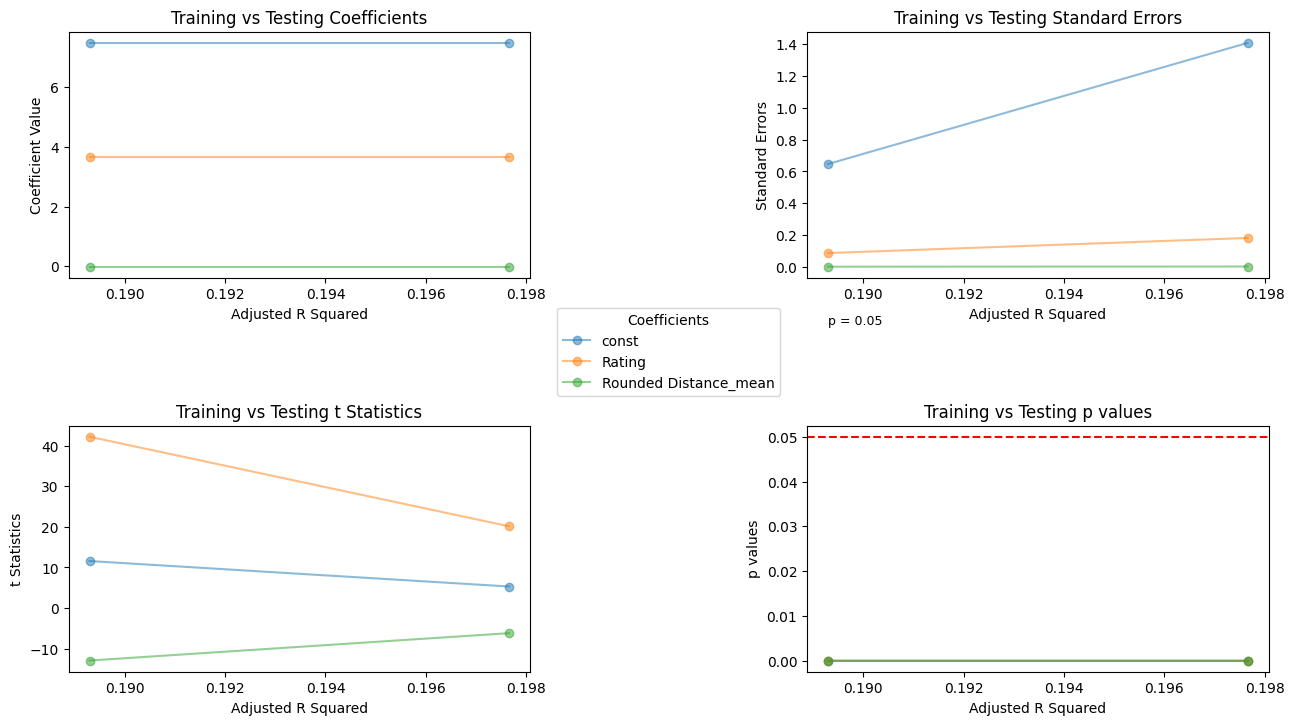

In [20]:
OLS4R2train, OLS4AdjR2train, OLS4MSEtrain, OLS4RMSEtrain, OLS4R2test, OLS4AdjR2test, OLS4MSEtest, OLS4RMSEtest = LinearRegressionModel(X_trainAdjusted3, X_testAdjusted3, numeric_y_train, numeric_y_test)

In [22]:
ResultsStore.AddResults('OLS4', OLS4R2train, OLS4AdjR2train, OLS4MSEtrain, OLS4RMSEtrain, OLS4R2test, OLS4AdjR2test, OLS4MSEtest, OLS4RMSEtest)

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Graph Information</h3>
<table>
  <tr>
    <th>Coefficients
    </th>
    <th>Standard Errors
    </th>
    <th>t statistics and p values
    </th>
  </tr>
  <tr>
    <td>Calculated based on the training data. This value should be and is the same for both training and testing data.<br>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
    <td>The variation in the means accross multiple data points.
    </td>
    <td>
      <p>(estimated coefficient) / (standard error)
      </p>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <p>Tells us how many standard errors away from zero the estimated coefficient is. The further away from zero the t-statistic is, the stronger evidence against the null hypothesis.
      </p>
    </td>
  </tr>
  <tr>
    <td>The coefficients are the same between training and testing. The graph indicates to us that the model calculations have been performed correctly.
    </td>
    <td>
      <p>The standard errors of the <span class='feature'>features</span> are relatively similar across the training and testing data. This indicates that the model is able to predict the testing data about the same as it is the training data. This suggests low overfitting.
      </p>
      <p> The relatively large change in standard error of the constant between training and testing suggests that the mean of the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is different between the training and testing data.
      </p>
    </td>
    <td>Both remaining <span class='feature'>features</span> <span class='feature'>Rating</span> and <span class='feature'>Rounded Distance Mean</span> are able to reject the null hypothesis for both training and testing data. No more features need to be dropped.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
    <th>Prob (F-statistic)
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
    <td>
      <p>Null hypothesis: a model made with only the constant coefficient value of 7.4900 is equal to this model made with the <span class='feature'>features Rounded Latitude</span>, <span class='feature'>Rounded Longitude</span>, <span class='feature'>Rating</span>, <span class='feature'>Rounded Distance</span>, and <span class='feature'>Rounded Distance_mean</span>.
      </p>
      <p>Reject null hypothesis: Prob (F-statistic) < 0.05
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.190
            </td>
            <td>0.199
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.189
            </td>
            <td>0.198
          </tr>
        </table>
      </div>
        <p>The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>49.697
            </td>
            <td>52.512
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>7.050
          </td>
          <td>7.246
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
        <p>The MSE has increased after removing Rounded Latitude as a <span class='feature'>feature</span>. With that said, the t-test is a clearer indication of a <span class='feature'>feature's</span> relevance to the model.
        </p>
    </td>
    <td rowspan>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.00
          </td>
          <td>0.00
          </td>
        </tr>
      </table>
        <p>
        </p>
      We can reject the null hypothesis and accept the alternate hypothesis that the model only using the constant coefficient value of 7.4900 is worse than this model made with the <span class='feature'>features</span> Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
    </td>
  </tr>
</table>

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Feature Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>P>|t|
    </th>
    <th>Coefficient
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>
      <p>t-test is run individually for each <span class='feature'>feature</span> in the model, taking it into consideration with the <span class='target'>target</span>.
      </p>
      <p>Null hypothesis for each <span class='feature'>feature</span>: the coefficient value is equal to 0; any changes made by the given <span class='feature'>feature</span> do not affect the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>.
      </p>
      <p>Reject null hypothesis: P>|t| < 0.05
      </p>
    </td>
    <td>
      <p>The model calculates that as one of the <span class='feature'>features</span> changes by 1, <span class='target'>Bike Spots Near</span> changes according to this number.
      </p>
      <p> <span class='highlight'> + </span> : <span class='feature'>feature</span> and <span class='target'>target</span> either both go up or both go down.
      </p>
      <p> <span class='highlight'> - </span> : <span class='feature'>feature</span> and <span class='target'>target</span> go in opposite directions.
      </p>
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td class='lower center'>
      <p>fail to reject: the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span> is most likely from natural variation as opposed to the number of bike spots being related to the <span class='feature'>feature</span>.
      </p>
      <table class='SplitRow'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>
      <p>As explained by the R-squared, adjusted R-squared, and p-values in the case of Rounded Latitude, Rounded Longitude, and Rounded Distance, the <span class='feature'>features</span> likely don't actually have any effect on the <span class='target'>target</span> of <span class='target'>Bike Spots Near</span>. 
      </p>
      <p>Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.
      <p>
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rating
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>+3.6591
    </td>
  </tr>
  <tr>
    <td>
      <span class='feature title'>Rounded Distance_mean
      </span>
    </td>
    <td class='center'>
      <table class = 'SplitRow'>
        <tr>
          <td>0.000
          </td>
          <td>0.000
          </td>
        </tr>
      </table>
      accept the alternative
    </td>
    <td>-0.0126
    </td>
  </tr>
</table>

In [23]:
def GraphCalcs(CalcsList):
    '''
    Takes the list of model calculations and graphs them in comparison to each other.

    Args:
        CalcsDict (list): A list containing the result dictionaries.

    Returns:
        2 graphs side by side with the Adjusted R-squared of the model on the x axis. The left graph compares against the RMSE of the model with test data. The right graph compares against the MSE of the model with test data. 
        
        RMSEdifference (float): The difference between the highest and lowest RMSE calculated using test data.
        MSEdifference (float): The difference between the highest and lowest MSE calculated using test data.

    '''

    # Get the information as a dataframe
    CalcsDF = pd.DataFrame(CalcsList)

    # Set up figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Compare RMSE and Adjusted R-squared
    sns.scatterplot(x='testModelAdjR2', y='testModelRMSE', data=CalcsDF,hue='model', ax=axes[0])
    axes[0].set_title('RMSE vs Adjusted R Sqared')

    # Compare MSE and Adjusted R-squared
    sns.scatterplot(x='testModelAdjR2', y='testModelMSE', data=CalcsDF,hue='model', ax=axes[1])
    axes[1].set_title('MSE vs Adjusted R Sqared')

    # compare RMSE between model with best RMSE and model with worst RMSE
    RMSEdifference = CalcsDF['testModelRMSE'].max() - CalcsDF['testModelRMSE'].min()
    RMSEdifference

    # compare MSE between model with best MSE and model with worst MSE
    MSEdifference = CalcsDF['testModelMSE'].max() - CalcsDF['testModelMSE'].min()
    MSEdifference

    return RMSEdifference, MSEdifference

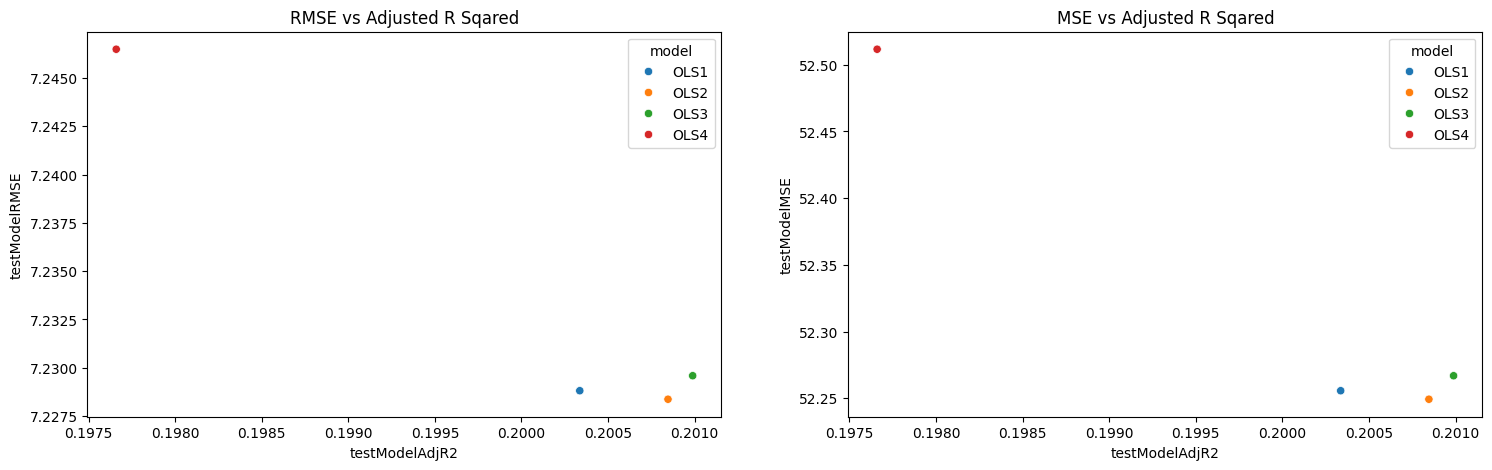

In [24]:
RMSEdifference, MSEdifference = GraphCalcs(ResultsStore.GetResults())

In [25]:
RMSEdifference

0.01812499162076886

In [26]:
MSEdifference

0.2623566676112077

'OLS4' is the only model where all features pass the t-test with both training data and testing data.

Comparing the models, we can make the following observations:
- The Adjusted R-squared for these Ordinary Least Squares models fall in the range of 0.1975 and 0.2010.
 - This is a difference of 0.0035, or 0.35%.
 - The model with the lowest Adjusted R-squared is able to explain less than 19.8% of the data.
 - The model with the highest Adjusted R-squared is able to explain less than 20.1% of the data.
 
This small difference means there is no significant loss when only using features that pass the t-test.
- The MSE is very similar accross all OSL models.
- The RMSE difference from the highest to lowest is 0.018, which doesn't account for much in terms of difference of average error of prediction.
- The MSE difference from the highest to lowest is 0.262. 0.262 isn't that consequential an average error when the target is the number of bike spots near, which is a whole number.

Now all of the model's features are able to reject the null hypothesis and accept the alternate hypothesis stating that the weight values of these particular features are non-zero. So Rating and Rounde Distance_mean both have an impact on predicting the amount of Bke Spots Near.

With that said, the model only explains 18.9% of the training data and 19.8% of the testing data.

# old model

In [21]:
ModelOutput = Model.summary()
print(ModelOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     467.7
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        10:46:35   Log-Likelihood:                -32868.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9729   BIC:                         6.579e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   610.61

The adjusted R-squared indicates to us that the model explains 19.3% of the data. The R-squared and adjusted R-squared being close to each other suggests that most of the features in the model are relevant to the prediction made.
___

The F-statistic for this model has a null hypothesis that a model made with only the constant coefficient value of 610.6147 is equal to this model made with the features Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean. The Prob (F-statistic) value being less than 0.05 is strong evidence against the null hypothesis. We can accept the alternate hypothesis that the model only using the constant coefficient is worse than this model made with the features Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
___

Our confidence interval for the t-test is 95%. The p values of Rounded Longitude and Rounded Distance are above the 0.05 threshold that we want. This means that the relationship between those two features and the number of bike spots in an area is most likely from natural variation as opposed to the number of bike spots being related to the feature.
___
For the other features (Rounded Latitude, Rating, and Rounded Distance_mean), the p values are below the 0.05 threshold. This means that those three features and the number of bike spots in an area are most likely related to each other.

___
As explained by the R-squared and p-values, the features likely don't actually have any effect on the target. Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.

The model's coefficient values show that as one of Rounded Longitude and Rating go up, the number of bike spots near goes up; when one of those values goes down, the number of bike spots goes down. The other features (Rounded Latitude, Rounded Distance, and Rounded Distance_mean) have a negative impact on the number of bike spots (when one goes up the other goes down, and vice versa). 

    The coefficient indicates that:
- as the Rounded Latitude increases by 1, the amount of bike spots is expected to decrease by 10.4190 on average. 
- as the Rounded Longitude increases by 1, the amount of bike spots is expected to increase by 1.0170 on average. 
- as the Rating increases by 1, the amount of bike spots is expected to increase by 3.583 on average.
- as the Rounded Distance increases by 1, the amount of bike spots is expected to decrease by 7.007e-10 on average, which is an extremely small number. 
- as the Rounded Distance_mean increases by 1, the amount of bike spots is expected to decrease by 0.0141 on average.

In [ ]:
# adjusting the model by removing the feature with the highest p-value
xAdjusted = X_Numeric.drop(columns=['Rounded Distance'])
xAdjusted = sm.add_constant(xAdjusted) # adding a constant
LinRegAdj = sm.OLS(y,xAdjusted)
ModelAdjusted = LinRegAdj.fit()
ModelAdjustedOutput = ModelAdjusted.summary()
print(ModelAdjustedOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     584.6
Date:                Wed, 05 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:40:57   Log-Likelihood:                -32868.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9730   BIC:                         6.578e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   610.61

Adjusting the model doesn't have the model explain any more of the data and it doesn't move the p values closer to the desired value of 0.05 or lower. We will remove the remaining feature that doesn't meet the desired value.

In [11]:
# adjusting the model by removing the feature with the highest p-value
xAdjusted2 = xAdjusted.drop(columns=['Rounded Longitude'])
xAdjusted2 = sm.add_constant(xAdjusted2) # adding a constant
LinRegAdj2 = sm.OLS(y,xAdjusted2)
ModelAdjusted2 = LinRegAdj2.fit()
ModelAdjustedOutput2 = ModelAdjusted2.summary()
print(ModelAdjustedOutput2)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     779.1
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:57:41   Log-Likelihood:                -32869.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9731   BIC:                         6.577e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   580.70

Now all of the model's features are able to reject the null hypothesis and accept the alternate hypothesis stating that the weight values of these particular features are non-zero. So Rounded Latitude, Rating, and Rounded Distance_mean all have an impact on predicting the amount of Bke Spots Near.

---

# Building a model using categorical features

In [27]:
# using label encoder
LabelEncoders = {}
for column in ['Name','Price','Category']:
    LabelEncoders[column] = LabelEncoder()
    YCRDataPrepared[column] = LabelEncoders[column].fit_transform(YCRDataPrepared[column])

In [28]:
X_Categoric = YCRDataPrepared[['Name','Price','Category']]
y = YCRDataPrepared['Bike Spots Near']

In [29]:
X_Categoric.head()

,Name,Price,Category
0,766,3,79
1,69,0,12
2,135,3,100
3,863,3,100
4,29,0,117


In [30]:
y.head()

0    28
1    16
2    14
3    24
4    16
Name: Bike Spots Near, dtype: int64

In [7]:
# checking for correlation, including the categorical data.
CategoricCorrelationMatrix = X_Categoric.corr(numeric_only=True)
CategoricCorrelationMatrix

,Name,Price,Category
Name,1.000000,0.070493,0.138376
Price,0.070493,1.000000,-0.026458
Category,0.138376,-0.026458,1.000000


In [35]:
HighlyCorrelatedFeatures(CategoricCorrelationMatrix)

,Feature 1,Feature 2,Correlation


There are no highly correlated categorical features.

In [31]:
# splitting data into training and testing
categoric_X_train, categoric_X_test, categoric_y_train, categoric_y_test = train_test_split(X_Categoric, y, test_size=0.2, random_state=42)

## comparing categoric and numeric y values

In [32]:
compareYtrain = categoric_y_train == numeric_y_train
compareYtrain.value_counts()

Bike Spots Near
True    7788
Name: count, dtype: int64

In [33]:
compareYtest = categoric_y_test == numeric_y_test
compareYtest.value_counts()

Bike Spots Near
True    1947
Name: count, dtype: int64

This confirms an identical train test split of the data.

## streamlining model

In [34]:
def xgbRegressorModel(X_train, X_test, y_train, y_test):
    '''
    Takes the split training and testing data. Trains an xgboost Regressor model. Displays calculations and visualizations that can be used to interpret the model's performance both on the training data and on the testing data.
    
    Args:
        X_train (DataFrame): To be used to train the model. The numerical features used to try to predict the specified target.
        X_test (DataFrame): To be used to test the model. The numerical features used to try to predict the specified target.
        y_train (DataFrame): To be used to train the model. The specified target that the model is trying to predict.
        y_test (DataFrame): To be used to test the model. The specified target that the model is trying to predict.

    Returns:
        A horizontal bar graph of the features of the model that shows the feature importance on the x-axis and the features on the y-axis. 

        trainModelR2 (float): the R-squared of the model's training data.
        trainModelAdjR2 (float): the Adjusted R-squared of the model's training data.
        trainModelMSE (float): the Mean Squared Error of the model's training data.
        trainModelRMSE (float): the Root Mean Squared Error of the model's training data.
        testModelR2 (float): the R-squared of the model's testing data.
        testModelAdjR2 (float): the Adjusted R-squared of the model's testing data.
        testModelMSE (float): the Mean Squared Error of the model's testing data.
        testModelRMSE (float): the Root Mean Squared Error of the model's testing data.
        
    '''

    # training the model
    # taking into account that the y value here is a continuous value
    xgbModel = xgb.XGBRegressor(objective='reg:squarederror')
    xgbModel.fit(X_train, y_train)

    print(f'Showing calculations made with X_train and y_train')
    trainModelR2, trainModelAdjR2, trainModelMSE, trainModelRMSE = ExplanationAndErrors(xgbModel, X_train, y_train)
    print(f'\nShowing calculations made with X_test and y_test')
    testModelR2, testModelAdjR2, testModelMSE, testModelRMSE = ExplanationAndErrors(xgbModel, X_test, y_test)
    # evaluating the relevance of each feature to the model

    # getting feature importance
    FeatureImportance = xgbModel.get_booster().get_score(importance_type='gain')
    
    # converting the results into a dataframe
    FeatureImportanceDF = pd.DataFrame(FeatureImportance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)
    

    # Set up figure
    fig, ax = plt.subplots()

    # RMSE
    ax.plot([trainModelAdjR2, testModelAdjR2]
            , [trainModelRMSE, testModelRMSE]
            , alpha=0.5
            , marker='o')

    ax.set_xlabel('Adjusted R Squared')
    ax.set_ylabel('Root Mean Squared Error')
    ax.set_title('Training vs Testing Root Mean Squared Error')

    plt.show()

    
    # Plot feature importance
    print(f'\nShowing the importance of specific features')
    plt.barh(FeatureImportanceDF['Feature'], FeatureImportanceDF['Importance'])
    plt.xlabel('Feature Importance (Gain)')
    plt.ylabel('Feature')
    plt.title('Feature Importance in XGBoost')
    plt.show()
    
    print(FeatureImportanceDF)
    return trainModelR2, trainModelAdjR2, trainModelMSE, trainModelRMSE, testModelR2, testModelAdjR2, testModelMSE, testModelRMSE

Showing calculations made with X_train and y_train
R^2: 0.9255830645561218
Adjusted R^2: 0.9255543838256064
Mean Squared Error: 4.563592433929443
Root Mean Squared Error: 2.1362566404646803

Showing calculations made with X_test and y_test
R^2: 0.9041170477867126
Adjusted R^2: 0.9039690041137122
Mean Squared Error: 6.285048007965088
Root Mean Squared Error: 2.506999802146998


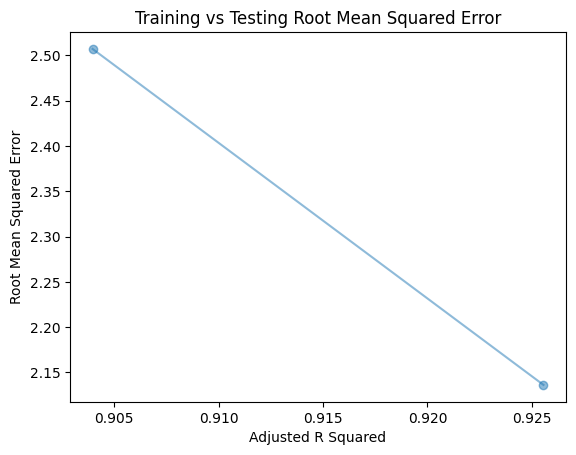


Showing the importance of specific features


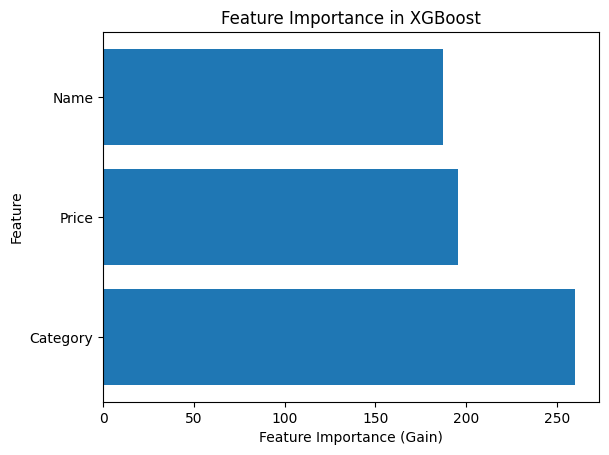

    Feature  Importance
2  Category  260.246338
1     Price  195.318512
0      Name  187.412354


In [35]:
XGB1R2train, XGB1AdjR2train, XGB1MSEtrain, XGB1RMSEtrain, XGB1R2test, XGB1AdjR2test, XGB1MSEtest, XGB1RMSEtest = xgbRegressorModel(categoric_X_train, categoric_X_test, categoric_y_train, categoric_y_test)

In [36]:
ResultsStore.AddResults('XGB1', XGB1R2train, XGB1AdjR2train, XGB1MSEtrain, XGB1RMSEtrain, XGB1R2test, XGB1AdjR2test, XGB1MSEtest, XGB1RMSEtest)

## Model Output and Interpretation

The gain is measuring the average improvement of the model's ability to predict the target when a feature is used.

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.926
            </td>
            <td>0.904
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.926
            </td>
            <td>0.904
          </tr>
        </table>
      </div>
        <p>The values above are rounded. The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>4.564
            </td>
            <td>6.285
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>2.136
          </td>
          <td>2.507
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
  </tr>
</table>

## Adjustment

In [37]:
# comparing without Name
X_Categoric_2 = YCRDataPrepared[['Price','Category']]
X_Categoric_2

,Price,Category
0,3,79
1,0,12
2,3,100
3,3,100
4,0,117
...,...,...
9730,0,92
9731,3,100
9732,2,115
9733,0,57


In [38]:
# splitting data into training and testing
categoric_X_train_2, categoric_X_test_2, categoric_y_train_2, categoric_y_test_2 = train_test_split(X_Categoric_2, y, test_size=0.2, random_state=42)

Showing calculations made with X_train and y_train
R^2: 0.5020133852958679
Adjusted R^2: 0.5018854503916408
Mean Squared Error: 30.53884506225586
Root Mean Squared Error: 5.52619625621963

Showing calculations made with X_test and y_test
R^2: 0.47913068532943726
Adjusted R^2: 0.47859481154891204
Mean Squared Error: 34.14254379272461
Root Mean Squared Error: 5.84316213986268


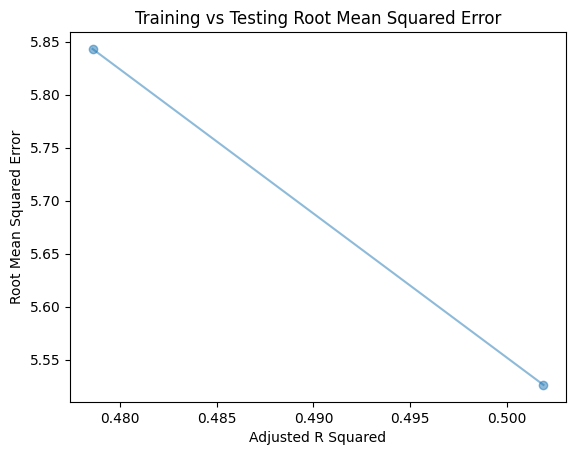


Showing the importance of specific features


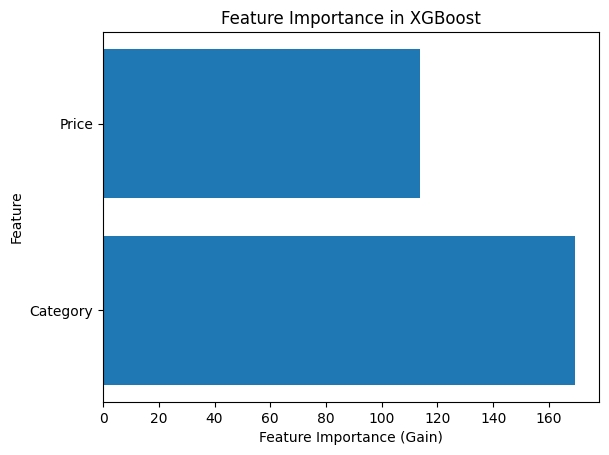

    Feature  Importance
1  Category  169.505844
0     Price  113.732826


In [39]:
XGB2R2train, XGB2AdjR2train, XGB2MSEtrain, XGB2RMSEtrain, XGB2R2test, XGB2AdjR2test, XGB2MSEtest, XGB2RMSEtest = xgbRegressorModel(categoric_X_train_2, categoric_X_test_2, categoric_y_train_2, categoric_y_test_2)

In [40]:
ResultsStore.AddResults('XGB2', XGB2R2train, XGB2AdjR2train, XGB2MSEtrain, XGB2RMSEtrain, XGB2R2test, XGB2AdjR2test, XGB2MSEtest, XGB2RMSEtest)

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.502
            </td>
            <td>0.479
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.502
            </td>
            <td>0.479
          </tr>
        </table>
      </div>
        <p>The values above are rounded. The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>30.539
            </td>
            <td>34.143
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>5.526
          </td>
          <td>5.843
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
  </tr>
</table>

The model using Name, Price, and Category is able to explain more of the data than this model that uses Price and Category.

# Comparing Against All Features

The numerical features selected above were able to reject the null hypothesis for the t-test. However, that doesn't necessarily impact how features will perform in XGBoost regression.

In [41]:
# gathering all features
X_Combined_Prepared = YCRDataPrepared.drop(columns=['Bike Spots Near'])
X_Combined_Prepared

,Name,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Category,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
0,766,60.163900,24.946410,993.930059,3,5.0,652.820553,104.417207,993.930059,79,60.164,24.946,993.930,652.821
1,69,60.157873,24.934694,906.269559,0,4.8,673.116165,83.377593,978.824142,12,60.158,24.935,906.270,673.116
2,135,60.157660,24.942540,489.112498,3,4.8,641.800023,134.034975,943.511457,100,60.158,24.943,489.112,641.800
3,863,60.163631,24.947679,910.667273,3,4.8,636.883659,122.448928,951.268827,100,60.164,24.948,910.667,636.884
4,29,60.157150,24.933661,941.072231,0,4.5,718.839949,163.361331,995.254401,117,60.157,24.934,941.072,718.840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9730,359,60.189571,24.917259,705.595387,0,3.3,511.016285,192.545596,902.743177,92,60.190,24.917,705.595,511.016
9731,729,60.183600,24.915930,542.047402,3,3.3,592.193958,190.699671,961.362096,100,60.184,24.916,542.047,592.194
9732,92,60.184929,24.941851,891.112679,2,4.0,858.743008,826.373336,891.112679,115,60.185,24.942,891.113,858.743
9733,170,60.184676,24.923223,125.893234,0,4.0,527.561874,125.893234,909.115155,57,60.185,24.923,125.893,527.562


In [42]:
# checking for correlation
AllCombinedCorrelationMatrix = X_Combined_Prepared.corr()
AllCombinedCorrelationMatrix

,Name,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Category,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
Name,1.000000,-0.011850,-0.015545,-0.004748,0.070493,0.019117,-0.014772,-0.038032,0.006196,0.138376,-0.012706,-0.015613,-0.004748,-0.014772
Latitude,-0.011850,1.000000,0.332180,-0.072395,0.087604,-0.291110,-0.225244,-0.141155,-0.127531,-0.206589,0.999970,0.332266,-0.072395,-0.225244
Longitude,-0.015545,0.332180,1.000000,0.010182,-0.042521,0.060689,0.031680,0.058445,-0.086827,-0.026281,0.331948,0.999994,0.010182,0.031680
Distance,-0.004748,-0.072395,0.010182,1.000000,-0.010702,0.045317,0.321408,0.216417,0.147196,0.008462,-0.072384,0.010194,1.000000,0.321408
Price,0.070493,0.087604,-0.042521,-0.010702,1.000000,-0.029353,-0.033298,-0.020833,-0.039389,-0.026458,0.087493,-0.042440,-0.010702,-0.033298
Rating,0.019117,-0.291110,0.060689,0.045317,-0.029353,1.000000,0.140995,0.000661,0.173716,0.095830,-0.291520,0.060767,0.045317,0.140995
Distance_mean,-0.014772,-0.225244,0.031680,0.321408,-0.033298,0.140995,1.000000,0.673341,0.457971,0.026329,-0.225208,0.031717,0.321408,1.000000
Distance_min,-0.038032,-0.141155,0.058445,0.216417,-0.020833,0.000661,0.673341,1.000000,-0.090176,0.005200,-0.141270,0.058352,0.216417,0.673340
Distance_max,0.006196,-0.127531,-0.086827,0.147196,-0.039389,0.173716,0.457971,-0.090176,1.000000,0.049794,-0.127487,-0.086773,0.147196,0.457971
Category,0.138376,-0.206589,-0.026281,0.008462,-0.026458,0.095830,0.026329,0.005200,0.049794,1.000000,-0.206750,-0.026335,0.008462,0.026329


In [45]:
HighlyCorrelatedFeatures(AllCombinedCorrelationMatrix)

,Feature 1,Feature 2,Correlation
0,Latitude,Rounded Latitude,0.999970
1,Longitude,Rounded Longitude,0.999994
2,Distance,Rounded Distance,1.000000
3,Distance_mean,Rounded Distance_mean,1.000000


The high correlations shown here are between features and their rounded counterparts.

In [46]:
# splitting the data
all_combined_X_train, all_combined_X_test, all_combined_y_train, all_combined_y_test = train_test_split(X_Combined_Prepared,y, test_size=0.2, random_state=42)

Showing calculations made with X_train and y_train
R^2: 0.9997934699058533
Adjusted R^2: 0.9997930979231802
Mean Squared Error: 0.012663664296269417
Root Mean Squared Error: 0.11253294760322159

Showing calculations made with X_test and y_test
R^2: 0.9990440607070923
Adjusted R^2: 0.9990371336107668
Mean Squared Error: 0.0626615360379219
Root Mean Squared Error: 0.2503228635940431


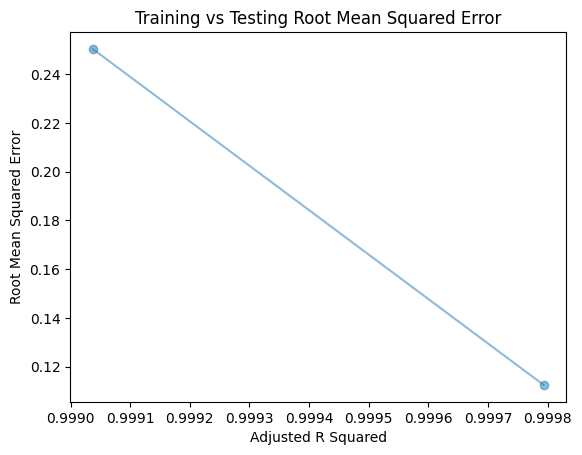


Showing the importance of specific features


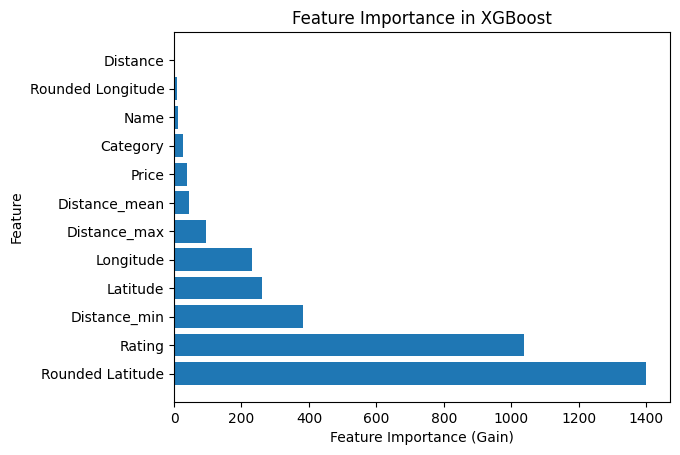

              Feature   Importance
10   Rounded Latitude  1400.312012
5              Rating  1037.502075
7        Distance_min   383.403320
1            Latitude   261.153076
2           Longitude   232.560898
8        Distance_max    96.046272
6       Distance_mean    44.529972
4               Price    39.093983
9            Category    27.570648
0                Name    12.112447
11  Rounded Longitude     9.925743
3            Distance     0.848411


In [47]:
XGBallR2train, XGBallAdjR2train, XGBallMSEtrain, XGBallRMSEtrain, XGBallR2test, XGBallAdjR2test, XGBallMSEtest, XGBallRMSEtest = xgbRegressorModel(all_combined_X_train, all_combined_X_test, all_combined_y_train, all_combined_y_test)

In [48]:
ResultsStore.AddResults('XGBall', XGBallR2train, XGBallAdjR2train, XGBallMSEtrain, XGBallRMSEtrain, XGBallR2test, XGBallAdjR2test, XGBallMSEtest, XGBallRMSEtest)

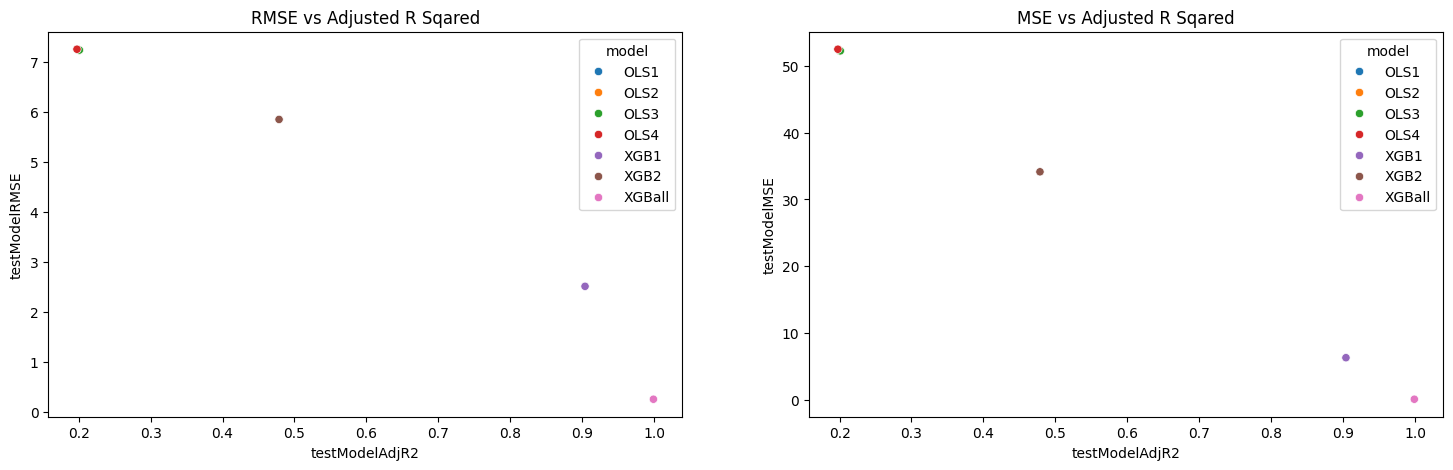

In [49]:
RMSEdifference, MSEdifference = GraphCalcs(ResultsStore.GetResults())

In [50]:
RMSEdifference

6.9961682915098145

In [51]:
MSEdifference

52.44897252496052

The XGBoost model that combines all features has the lowest error of all models and explains the highest amount of data. 

The result is better than the combined model that only uses numerical features that passed the t-test from the OLS model.
This is because the t-test results from the Ordinary Least Squares model explain the relation of features and the target within a Linear Regression framework, which isn't directly related to XGBoost Regression. Linear Regression finds the best fitting line to use for each feature and makes predictions using these lines. XGBoost takes a less linear approach.

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Model Information</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>R-squared
    </th>
    <th>Adjusted R-squared
    </th>
    <th>Mean Squared Error
    </th>
    <th>Root Mean Squared Error
    </th>
  </tr>
  <tr>
    <td>
    </td>
    <td>How much of the data the model is able to explain. Multiply the value by 100 to get the percentage of data that is explained by the model.
    </td>
    <td>Adjusting R-squared by taking into account the amount of <span class='feature'>features</span> and how they affect the model.
    </td>
    <td>MSE emphasizes errors because it squares the errors that occur. MSE tells us the square of what predictions are off by on average.
    </td>
    <td>RMSE is on the same scale as the <span class='target'>target</span>, making it more interpretable. RMSE tells us what predictions are off by on average.
    </td>
  </tr>
  <tr>
    <td class='title'>Constant/Whole Model
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.9998
            </td>
            <td>0.9990
            </td>
          </tr>
        </table>
              <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.9998
            </td>
            <td>0.9990
          </tr>
        </table>
      </div>
        <p>The values above are rounded. The adjusted R-squared being slightly lower than the R-squared suggests that most of the <span class='feature'>features</span> in the model are relevant to the prediction made.
        </p>
        <p>The adjusted R-squared on the testing data is higher for this combined model than the previous best combined model. This indicates that the model is able to explain more of the data it wasn't trained on than the previous best combined model that uses Name, Price, Category, Rounded Distance_mean, and Rating.
        </p>
        <p>
          The results from test data being higher by 1% could be from:
        </p>
          <br>
            - random variation in the data
          <br>
            - the training data containing more noise than the test data
          <br>
            - the model having good generalization and being able to handle data outside of the training data
    </td>
    <td colspan='2'>
      <div class='multi'>
        <table class='center'>
          <tr>
            <th>training
            </th>
            <th>testing
            </th>
          </tr>
          <tr>
            <td>0.013
            </td>
            <td>0.063
            </td>
          </tr>
        </table>
      <table class='center'>
        <tr>
          <th>training
          </th>
          <th>testing
          </th>
        </tr>
        <tr>
          <td>0.113
          </td>
          <td>0.250
          </td>
        </tr>
      </table>
      </div>
        <p>Both the MSE and RMSE being higher for testing than training indicates the model is better able to predict the training data. 
        </p>
        <p>The relatively small difference between MSE values tells us that the model isn't overfitting.
        </p>
    </td>
  </tr>
</table>

## Adjustments to remove correlated features

There are correlated features in the model. We can remove the ones that have less impact on the model. Of the correlated features, Rounded Distance_mean wasn't considered important enough to be counted as an impactful feature to the model and Latitude, Rounded Longitude, and Distance had lower importances than their correlated counterparts.

In [52]:
combined_X_train_2 = all_combined_X_train.drop(columns=['Rounded Distance_mean', 'Distance', 'Rounded Longitude', 'Latitude'])
combined_X_test_2 = all_combined_X_test.drop(columns=['Rounded Distance_mean', 'Distance', 'Rounded Longitude', 'Latitude'])
print(f'total columns in combined_X_train_2 = total columns in combined_X_test_2: {len(combined_X_train_2.columns) == len(combined_X_test_2.columns)}')

total columns in combined_X_train_2 = total columns in combined_X_test_2: True


Showing calculations made with X_train and y_train
R^2: 0.9998373985290527
Adjusted R^2: 0.9998371894491107
Mean Squared Error: 0.009971994906663895
Root Mean Squared Error: 0.09985987636014725

Showing calculations made with X_test and y_test
R^2: 0.9988132119178772
Adjusted R^2: 0.9988070818141472
Mean Squared Error: 0.07779239863157272
Root Mean Squared Error: 0.2789128871737065


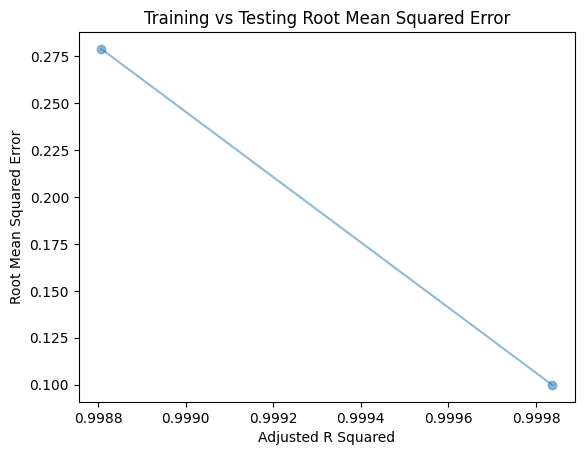


Showing the importance of specific features


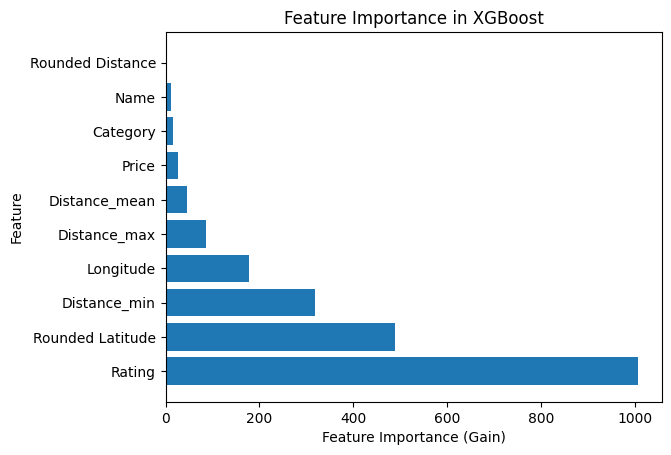

            Feature   Importance
3            Rating  1007.107178
8  Rounded Latitude   489.934540
5      Distance_min   318.215088
1         Longitude   178.642380
6      Distance_max    85.767555
4     Distance_mean    45.779732
2             Price    26.957310
7          Category    14.737625
0              Name    10.546209
9  Rounded Distance     0.688761


In [53]:
XGBallR2train2, XGBallAdjR2train2, XGBallMSEtrain2, XGBallRMSEtrain2, XGBallR2test2, XGBallAdjR2test2, XGBallMSEtest2, XGBallRMSEtest2 = xgbRegressorModel(combined_X_train_2, combined_X_test_2, all_combined_y_train, all_combined_y_test)

In [54]:
ResultsStore.AddResults('XGBall2', XGBallR2train2, XGBallAdjR2train2, XGBallMSEtrain2, XGBallRMSEtrain2, XGBallR2test2, XGBallAdjR2test2, XGBallMSEtest2, XGBallRMSEtest2)

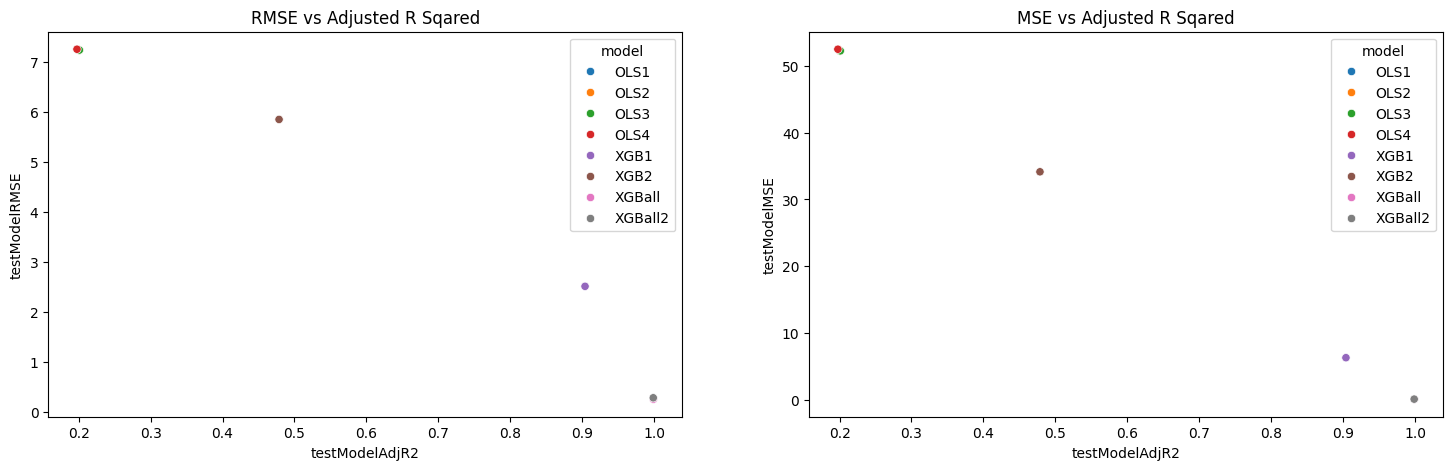

In [55]:
RMSEdifference, MSEdifference = GraphCalcs(ResultsStore.GetResults())

The combined model with removed correlated features has a slightly lower Adjusted R Squared and slightly higher Mean Squared Errors. This model is the best performimg model. 

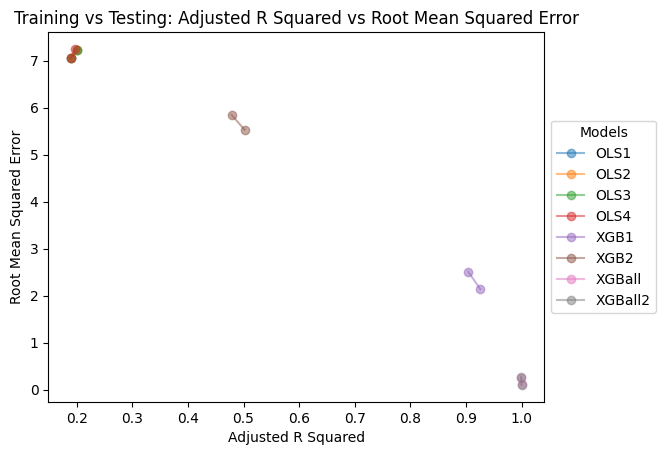

In [87]:
# Set up color
allModels = ResultsStore.GetResults()
graphColours = plt.cm.tab10(np.arange(len(allModels))) 

# Set up figure
fig, ax = plt.subplots()

# RMSE
for i, model in enumerate(allModels):
    ax.plot([model['trainModelAdjR2'], model['testModelAdjR2']]
            , [model['trainModelRMSE'], model['testModelRMSE']]
            , alpha=0.5
            , color=graphColours[i]
            , marker='o'
            , label=model.get('model', f'Model {i+1}'))
    
ax.set_xlabel('Adjusted R Squared')
ax.set_ylabel('Root Mean Squared Error')
ax.set_title('Training vs Testing: Adjusted R Squared vs Root Mean Squared Error')
# Add legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Models")
plt.show()

# Conclusion

<style>
table, td, th {
  border: 1 solid;
}
th {
  text-align: center;
}

td {
  vertical-align: top;
}

.center {
  margin-left: auto;
  margin-right: auto;
  text-align: center;
}

.SplitRow {
  border: 1;
  width: 100%;
  text-align: center;
  bottom: 0; 
}

.CombinedTable {
  height: 100%
}

.feature {
  text-decoration: underline double #913503;
}

.target {
  text-decoration: underline double #0154a2;
}

.title {
  font-weight: bold;
  vertical-align: middle;
}

.lower {
  vertical-align: bottom;
}

.empty {
  color: #403d3d;
}

.multi {
  display: flex;
  gap: 10px;
}

.highlight {
  border-style: solid;
}

</style>
<h3>Models Tested</h3>
<table>
  <tr>
    <th> 
    </th>
    <th>Numerical only
    </th>
    <th>Categorical only
    </th>
    <th>Combined features
    </th>
  </tr>
  <tr>
    <td class='title'>Model Choice
    </td>
    <td><span class='title'>Ordinary Least Squares Regression.</span>
      <br>
    </td>
    <td>
    </td>
    <td>
    </td>
  </tr>
  <tr>
    <td class='title'>Best Model Results
    </td>
    <td>
    </td>
    <td>
    </td>
    <td>
    </td>
  </tr>
</table>

Of the models tested, the best model to predict the amount of Bike Spots near is the [combined model that uses the categorical features Price and Category and the numerical features Rounded Distance_mean and Rating.](#combining-features)